<a href="https://colab.research.google.com/github/cheecaixi/elderguard-project/blob/main/cleaning_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Load Data**

In [1]:
# Import Libraries
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
# Connect to the SQLite database
DB_PATH = "/content/gas_monitoring.db"
conn = sqlite3.connect(DB_PATH)

# Read data from a table (assuming the main table is also named 'gas_monitoring')
df = pd.read_sql_query("SELECT * FROM gas_monitoring", conn)

# Close the connection
conn.close()

In [3]:
display(df)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,evening,23.45,NaN,137.854649,544.124855,510.926349,NaN,680.916215,620.292682,1.0,2586,maintenance_mode,very_bright,Low Activity
9996,evening,297.24,46.98,131.945968,541.756022,517.719693,738.901193,689.383365,625.100827,2.0,2586,ventilation_only,very_dim,Low Activity
9997,evening,23.71,49.16,136.422868,542.072190,512.607291,732.456099,683.197988,622.035384,2.0,2586,eco_mode,very_bright,Low Activity
9998,night,20.58,NaN,126.734430,561.716292,435.638480,707.447312,648.634308,581.583550,1.0,4761,cooling_active,very_bright,Low Activity


In [4]:
# The inital Shape of the dataset before cleaning
print(df.shape)

(10000, 14)


In [5]:
print("\nDataset Summary:")

# Re-identify numerical and categorical columns after cleaning
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

summary = pd.DataFrame({
    'Dtype': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum()
})

summary['Column Type'] = 'Other'
summary.loc[numerical_cols, 'Column Type'] = 'Numerical'
summary.loc[categorical_cols, 'Column Type'] = 'Categorical'

# Drop the 'Dtype' column as requested
summary = summary.drop(columns=['Dtype'])

display(summary)


Dataset Summary:


,Non-Null Count,Missing Values,Column Type
Time of Day,10000,0,Categorical
Temperature,10000,0,Numerical
Humidity,8072,1928,Numerical
CO2_InfraredSensor,10000,0,Numerical
CO2_ElectroChemicalSensor,10000,0,Numerical
MetalOxideSensor_Unit1,10000,0,Numerical
MetalOxideSensor_Unit2,8590,1410,Numerical
MetalOxideSensor_Unit3,10000,0,Numerical
MetalOxideSensor_Unit4,10000,0,Numerical
CO_GasSensor,9166,834,Numerical


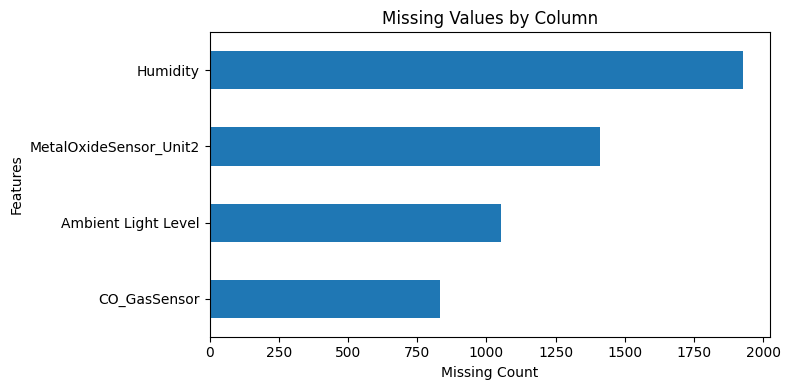

In [6]:
# Visualise missing values by column

missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
plt.figure(figsize=(8,4))
missing_counts.sort_values().plot(kind="barh")

plt.title("Missing Values by Column")
plt.xlabel("Missing Count")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

The dataset contains 10,000 records with a mix of categorical and numerical features related to environmental and sensor data.

Most columns are complete with no missing values, indicating generally good data quality.

However, several attributes such as
- Humidity (1,928 missing values)
- MetalOxideSensor_Unit2 (1,410 missing values)
- Ambient Light Level (1,054 missing values)
- CO_GasSensor (834 missing values)
- Ambient_Light_Ordinal (1054 missing values)

require data cleaning or handling before analysis.

The dataset also includes engineered features like CO2_Disagreement, MOS_Mean, Is_Night, and Activity_Encoded, which may help improve predictive analysis and pattern detection.

# **2. Standardize Categories**

In [7]:
categorical_columns = [
    "HVAC Operation Mode",
    "Activity Level"
]

print("Category Counts BEFORE Standardization\n")

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))

Category Counts BEFORE Standardization


HVAC Operation Mode
HVAC Operation Mode
cooling_active      1502
maintenance_mode    1500
heating_active      1468
off                 1456
eco_mode            1452
ventilation_only    1394
COOLING_ACTIVE       112
ECO_MODE             112
MAINTENANCE_MODE     106
Off                  103
VENTILATION_ONLY      98
HEATING_ACTIVE        98
OFF                   93
Cooling_Active        64
Eco_mode              56
Eco_Mode              53
Heating_active        50
Cooling_active        50
Maintenance_Mode      49
Maintenance_mode      48
Ventilation_Only      47
Ventilation_only      45
Heating_Active        44
Name: count, dtype: int64

Activity Level
Activity Level
Low Activity         5244
Moderate Activity    2812
High Activity        1095
ModerateActivity      326
Low_Activity          285
LowActivity           238
Name: count, dtype: int64


In [8]:
# HVAC Operation Mode
df["HVAC Operation Mode"] = (
    df["HVAC Operation Mode"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Activity Level
df["Activity Level"] = (
    df["Activity Level"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("_", " ", regex=False)
)

# Merge concatenated variants
df["Activity Level"] = df["Activity Level"].replace({
    "lowactivity": "low activity",
    "moderateactivity": "moderate activity",
    "highactivity": "high activity"
})

In [9]:
# Display all unique values and counts for categorical columns

categorical_columns = [
    "Time of Day",
    "HVAC Operation Mode",
    "Ambient Light Level",
    "Activity Level"
]

for col in categorical_columns:
    print(f"{col}")
    print(f"Unique Categories: {df[col].nunique()}\n")
    print(df[col].value_counts(dropna=False))

Time of Day
Unique Categories: 4

Time of Day
afternoon    2635
evening      2476
morning      2460
night        2429
Name: count, dtype: int64
HVAC Operation Mode
Unique Categories: 6

HVAC Operation Mode
cooling_active      1728
maintenance_mode    1703
eco_mode            1673
heating_active      1660
off                 1652
ventilation_only    1584
Name: count, dtype: int64
Ambient Light Level
Unique Categories: 5

Ambient Light Level
very_bright    3387
bright         2697
moderate       1463
None           1054
dim             864
very_dim        535
Name: count, dtype: int64
Activity Level
Unique Categories: 3

Activity Level
low activity         5767
moderate activity    3138
high activity        1095
Name: count, dtype: int64


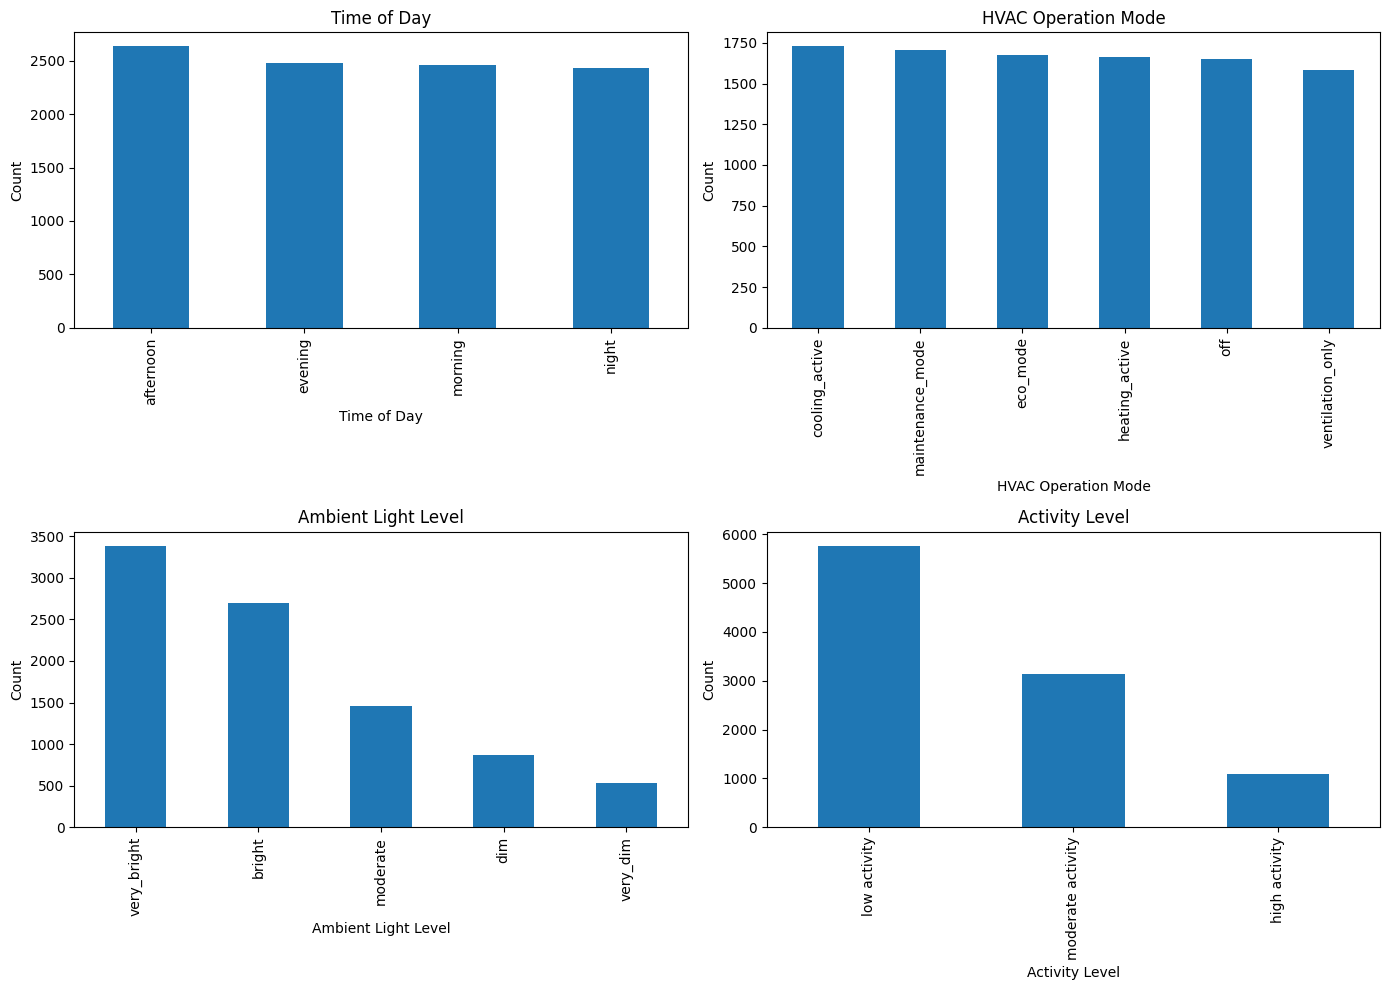

In [10]:
# Visualise category counts before standardisation

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):

    df[col].value_counts().plot(
        kind="bar",
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

Several category inconsistencies were identified in the HVAC Operation Mode and Activity Level features. Variations caused by capitalization, underscores, and inconsistent naming conventions were standardized to ensure that identical categories were represented consistently. This reduces redundancy and improves the quality of subsequent encoding and analysis.

# **3. Correct Data Types**

In [11]:
# Record dtypes BEFORE correction for comparison
dtypes_before = df.dtypes.copy()
memory_before = df.memory_usage(deep=True).sum()

print("Data types BEFORE correction:")
print(dtypes_before)

Data types BEFORE correction:
Time of Day                   object
Temperature                  float64
Humidity                     float64
CO2_InfraredSensor           float64
CO2_ElectroChemicalSensor    float64
MetalOxideSensor_Unit1       float64
MetalOxideSensor_Unit2       float64
MetalOxideSensor_Unit3       float64
MetalOxideSensor_Unit4       float64
CO_GasSensor                 float64
Session ID                     int64
HVAC Operation Mode           object
Ambient Light Level           object
Activity Level                object
dtype: object


In [12]:
# Convert sensor and numerical columns to numeric format
float_columns = [
    "Temperature", "Humidity",
    "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor",
    "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2",
    "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4",
    "CO_GasSensor"
]

for col in float_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Session ID is treated as an identifier rather than a numerical feature
df["Session ID"] = df["Session ID"].astype(str)

# Convert categorical text features to category dtype
categorical_columns = [
    "Time of Day",
    "HVAC Operation Mode",
    "Ambient Light Level",
    "Activity Level"
]

for column in categorical_columns:
    df[column] = df[column].astype("category")

print("Data Types After Correction:")
print(df.dtypes)

Data Types After Correction:
Time of Day                  category
Temperature                   float64
Humidity                      float64
CO2_InfraredSensor            float64
CO2_ElectroChemicalSensor     float64
MetalOxideSensor_Unit1        float64
MetalOxideSensor_Unit2        float64
MetalOxideSensor_Unit3        float64
MetalOxideSensor_Unit4        float64
CO_GasSensor                  float64
Session ID                     object
HVAC Operation Mode          category
Ambient Light Level          category
Activity Level               category
dtype: object


In [13]:
# Compare data types before and after correction
dtype_comparison = pd.DataFrame({
    "Before": dtypes_before,
    "After": df.dtypes
})

print(dtype_comparison)

                            Before     After
Time of Day                 object  category
Temperature                float64   float64
Humidity                   float64   float64
CO2_InfraredSensor         float64   float64
CO2_ElectroChemicalSensor  float64   float64
MetalOxideSensor_Unit1     float64   float64
MetalOxideSensor_Unit2     float64   float64
MetalOxideSensor_Unit3     float64   float64
MetalOxideSensor_Unit4     float64   float64
CO_GasSensor               float64   float64
Session ID                   int64    object
HVAC Operation Mode         object  category
Ambient Light Level         object  category
Activity Level              object  category


In [14]:
# Memory usage comparison: before vs after dtype corrections
memory_after = df.memory_usage(deep=True).sum()

print(f"Memory BEFORE dtype correction : {memory_before / 1024:.1f} KB")
print(f"Memory AFTER  dtype correction : {memory_after  / 1024:.1f} KB")
print(f"Memory saved                   : {(memory_before - memory_after) / 1024:.1f} KB "
      f"({100 * (memory_before - memory_after) / memory_before:.1f}% reduction)")

Memory BEFORE dtype correction : 3058.0 KB
Memory AFTER  dtype correction : 1261.5 KB
Memory saved                   : 1796.4 KB (58.7% reduction)


In [15]:
# Final validation after dtype correction
coercion_nulls = df[float_columns].isnull().sum()

if coercion_nulls.sum() > 0:
    print("Warning - coercion introduced NaNs in:")
    print(coercion_nulls[coercion_nulls > 0])
else:
    print("No new NaNs introduced by dtype coercion.")

print(f"\nFinal dataset shape: {df.shape}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Warning - coercion introduced NaNs in:
Humidity                  1928
MetalOxideSensor_Unit2    1410
CO_GasSensor               834
dtype: int64

Final dataset shape: (10000, 14)
Remaining missing values: 5226


Several features were converted to more appropriate data types based on their role within the dataset. Numerical sensor measurements were stored as numeric values, categorical variables were converted to category dtype, and binary indicators were optimized using smaller integer types. These changes improved memory efficiency while preserving data integrity, and validation confirmed that no new missing values were introduced during the conversion process.

# **4. Handle Missing Values & Fix Invalid Values**

In [16]:
print(f"\nMissing values: {df.isnull().sum().sum()}")


Missing values: 5226


In [17]:
# Overview of missing values
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_pct.round(2)
}).query("`Missing Count` > 0")

print("Missing Values Summary:")
print(missing_summary)

Missing Values Summary:
                        Missing Count  Missing %
Humidity                         1928      19.28
MetalOxideSensor_Unit2           1410      14.10
CO_GasSensor                      834       8.34
Ambient Light Level              1054      10.54


Which columns has missing values, and the percentage of the missing values

In [18]:
# Understand data distribution before choosing imputation methods
columns_with_missing = [
    "Humidity",
    "MetalOxideSensor_Unit2",
    "CO_GasSensor"
]

print("\nStatistics for Columns with Missing Values:")
print(
    df[columns_with_missing]
    .agg(["mean", "median", "std", "min", "max"])
    .round(4)
)


Statistics for Columns with Missing Values:
        Humidity  MetalOxideSensor_Unit2  CO_GasSensor
mean     51.6436                728.3544        1.2882
median   51.3900                726.7489        1.0000
std      21.3339                 29.1401        0.7798
min     -49.8700                611.1689        0.0000
max     198.9000                807.7329        4.0000


Understanding the distribution of numerical features and determine whether median or mean imputation is more suitable.

In [19]:
# Remove physically impossible sensor readings
before = df.shape[0]

df = df[(df["Humidity"] >= 0) & (df["Humidity"] <= 100)]
df = df[(df["Temperature"] >= -20) & (df["Temperature"] <= 60)]
df = df[df["CO2_InfraredSensor"] >= 0]
df = df[df["CO_GasSensor"] >= 0]

rows_removed = before - df.shape[0]

print(f"\nRows removed due to invalid sensor values: {rows_removed}")
print(f"Dataset shape after cleaning: {df.shape}")


Rows removed due to invalid sensor values: 3599
Dataset shape after cleaning: (6401, 14)


Remove physically impossible sensor readings that may reduce data quality and negatively affect model performance.

In [20]:
# Median imputation for numerical sensor data
num_impute_cols = [
    "Humidity",
    "MetalOxideSensor_Unit2",
    "CO_GasSensor"
]

for col in num_impute_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

    print(f"{col:<30} imputed using median: {median_val:.4f}")

Humidity                       imputed using median: 51.4200
MetalOxideSensor_Unit2         imputed using median: 726.7827
CO_GasSensor                   imputed using median: 1.0000


Replace missing numerical sensor values using the median, which is more robust against skewed data and outliers.

In [21]:
# Maintain consistency between categorical and ordinal columns
if "Ambient_Light_Ordinal" not in df.columns:
    ambient_light_order = {
        'very_dim': 0,
        'dim': 1,
        'moderate': 2,
        'bright': 3,
        'very_bright': 4
    }


    df["Ambient_Light_Ordinal"] = df["Ambient Light Level"].map(ambient_light_order)
    print("Created 'Ambient_Light_Ordinal' column based on 'Ambient Light Level' mapping.")

# Now proceed with the original logic to fill missing values consistently
ambient_mode_label = df["Ambient Light Level"].mode()[0]

ambient_mode_ordinal = (
    df.loc[
        df["Ambient Light Level"] == ambient_mode_label,
        "Ambient_Light_Ordinal"
    ]
    .mode()[0]
)

# Fill missing rows consistently
missing_ambient = df["Ambient Light Level"].isna()
df.loc[missing_ambient, "Ambient Light Level"] = ambient_mode_label
df.loc[missing_ambient, "Ambient_Light_Ordinal"] = ambient_mode_ordinal

print(f"{'Ambient Light Level':<30} mode: '{ambient_mode_label}'")
print(f"{'Ambient_Light_Ordinal':<30} synced ordinal: {ambient_mode_ordinal}")

Created 'Ambient_Light_Ordinal' column based on 'Ambient Light Level' mapping.
Ambient Light Level            mode: 'very_bright'
Ambient_Light_Ordinal          synced ordinal: 4


Fill missing categorical values while maintaining consistency between categorical labels and ordinal encoded values.

In [22]:
# Final validation
print("\nRemaining Missing Values:")
print(df.isnull().sum())

print(f"\nTotal Remaining Missing Values: {df.isnull().sum().sum()}")


Remaining Missing Values:
Time of Day                  0
Temperature                  0
Humidity                     0
CO2_InfraredSensor           0
CO2_ElectroChemicalSensor    0
MetalOxideSensor_Unit1       0
MetalOxideSensor_Unit2       0
MetalOxideSensor_Unit3       0
MetalOxideSensor_Unit4       0
CO_GasSensor                 0
Session ID                   0
HVAC Operation Mode          0
Ambient Light Level          0
Activity Level               0
Ambient_Light_Ordinal        0
dtype: int64

Total Remaining Missing Values: 0


Median imputation was selected because several sensor related features showed potential skewness and outlier presence. Invalid sensor readings were removed before imputation to improve overall data reliability. After preprocessing, all missing values were successfully handled and the dataset became more suitable for machine learning preparation.

# **5. Remove Duplicates**

In [23]:
# Remove duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows Found: {duplicate_count}")

df = df.drop_duplicates()
print(f"Shape After Removing Duplicates: {df.shape}")


Duplicate Rows Found: 261
Shape After Removing Duplicates: (6140, 15)


Removing duplicates helps improve data accuracy and prevents repeated records from affecting the reliability of the analysis and model results.

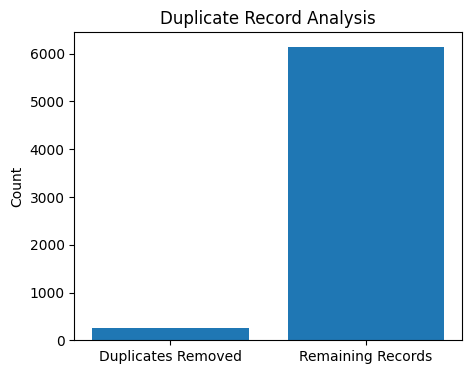

In [24]:
# Visualise duplicate removal
plt.figure(figsize=(5, 4))
duplicate_count = 265

plt.bar(
    ["Duplicates Removed", "Remaining Records"],
    [duplicate_count, len(df)]
)

plt.title("Duplicate Record Analysis")
plt.ylabel("Count")

plt.show()

# **6. Detect and Handle Outliers**

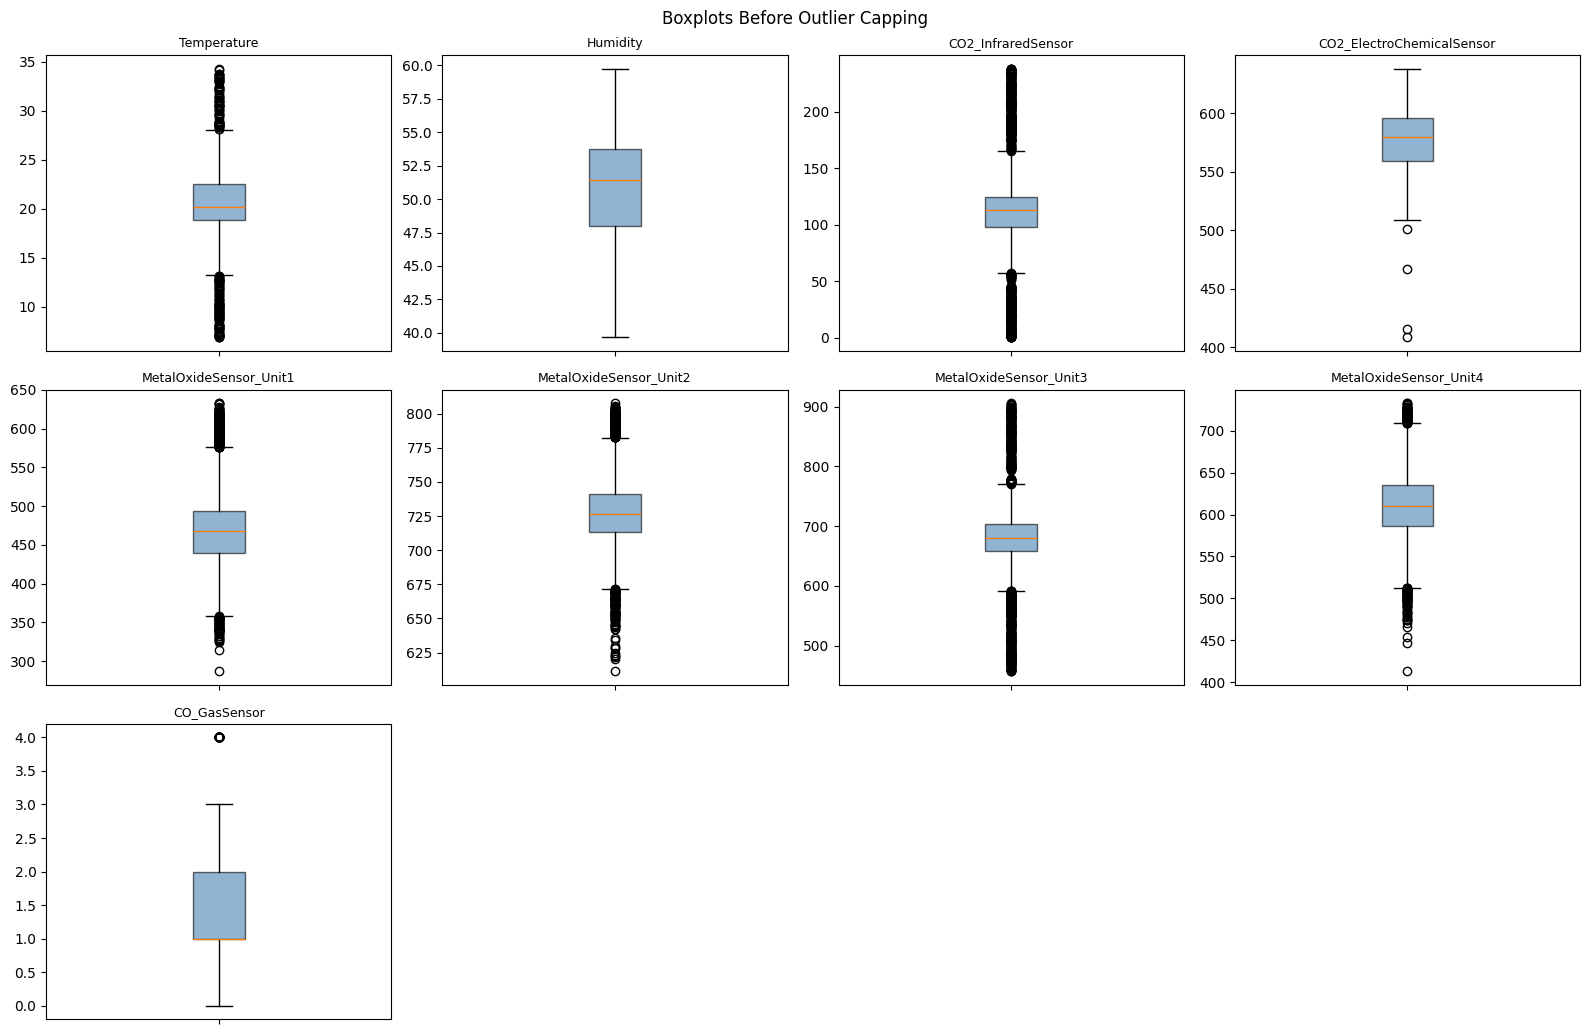

In [25]:
# Visualise outliers with boxplots before capping

# Columns to check for statistical outliers (copied from a later cell for self-containment)
all_outlier_columns = [
    "Temperature", "Humidity", "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor", "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2", "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4", "CO_GasSensor",
    "CO2_Disagreement", "MOS_Mean"
]

# Filter to include only columns that exist in the DataFrame
outlier_columns = [col for col in all_outlier_columns if col in df.columns]

# Check if there are any columns left to plot
if not outlier_columns:
    print("No outlier columns found in DataFrame to plot.")
else:
    # Adjust subplot grid based on the number of actual outlier columns
    num_cols = len(outlier_columns)
    num_rows = (num_cols + 3) // 4 # Calculate rows needed for up to 4 columns per row
    fig, axes = plt.subplots(num_rows, 4, figsize=(16, num_rows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(outlier_columns):
        axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor="steelblue", alpha=0.6))
        axes[i].set_title(col, fontsize=9)
        axes[i].tick_params(axis="x", labelbottom=False)

    # Hide unused subplots
    for j in range(len(outlier_columns), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Boxplots Before Outlier Capping", fontsize=12)
    plt.tight_layout()
    plt.show()

In [26]:
# Columns to check for statistical outliers
# We skip encoded/flag columns (Is_Night, Activity_Encoded, Ambient_Light_Ordinal)
all_outlier_columns = [
    "Temperature", "Humidity", "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor", "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2", "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4", "CO_GasSensor",
    "CO2_Disagreement", "MOS_Mean"
]

# Filter to include only columns that exist in the DataFrame
outlier_columns = [col for col in all_outlier_columns if col in df.columns]

# IQR method: flag values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
outlier_report = {}
for col in outlier_columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {"lower": lower, "upper": upper, "outliers": n_out}

outlier_df = pd.DataFrame(outlier_report).T
print("Outlier summary (IQR method):")
print(outlier_df.to_string())

Outlier summary (IQR method):
                                lower       upper  outliers
Temperature                 13.255000   28.175000     164.0
Humidity                    39.310000   62.350000       0.0
CO2_InfraredSensor          57.300771  165.203884     465.0
CO2_ElectroChemicalSensor  504.980029  649.810472       4.0
MetalOxideSensor_Unit1     358.194872  575.776760     357.0
MetalOxideSensor_Unit2     671.303601  782.597540     371.0
MetalOxideSensor_Unit3     591.687355  771.026082     496.0
MetalOxideSensor_Unit4     512.360711  708.991871     202.0
CO_GasSensor                -0.500000    3.500000      47.0


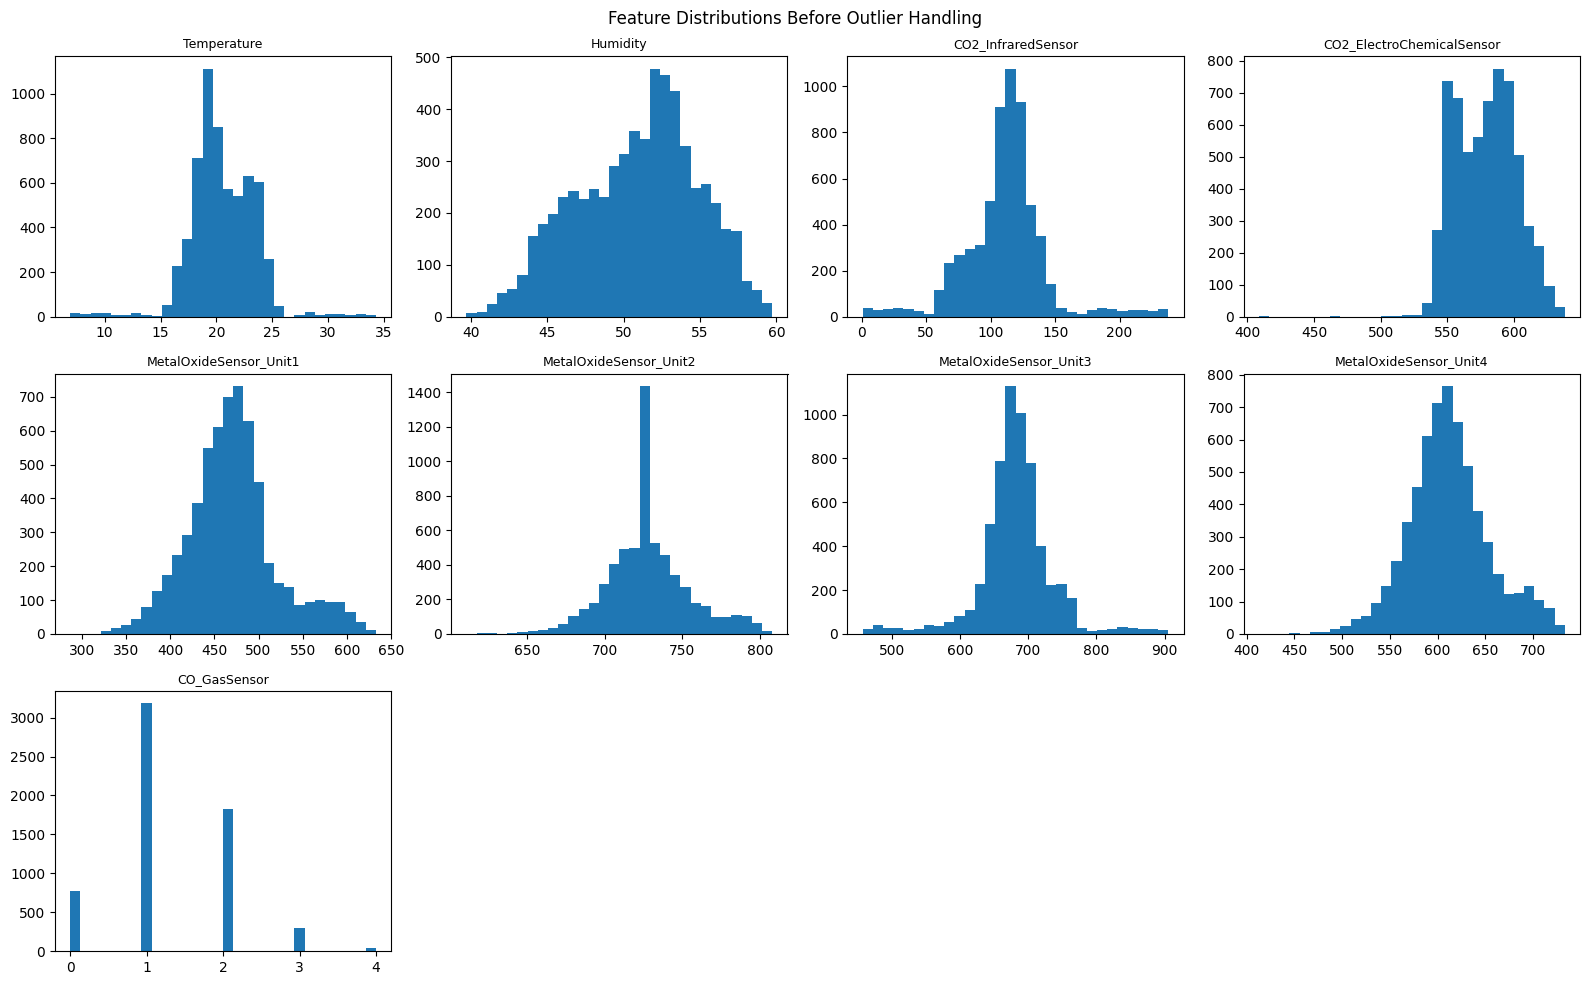

In [27]:
# Visualise distributions before outlier handling
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_columns):

    axes[i].hist(
        df[col].dropna(),
        bins=30
    )

    axes[i].set_title(col, fontsize=9)

for j in range(len(outlier_columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions Before Outlier Handling")

plt.tight_layout()
plt.show()

In [28]:
# Cap outliers using Winsorization (clip to IQR bounds)
# This keeps the row but pulls extreme values to the fence — no data is lost
for col in outlier_columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outlier capping complete.")
print(f"Shape after capping: {df.shape}")
print(f"Missing values after capping: {df.isnull().sum().sum()}")

Outlier capping complete.
Shape after capping: (6140, 15)
Missing values after capping: 0


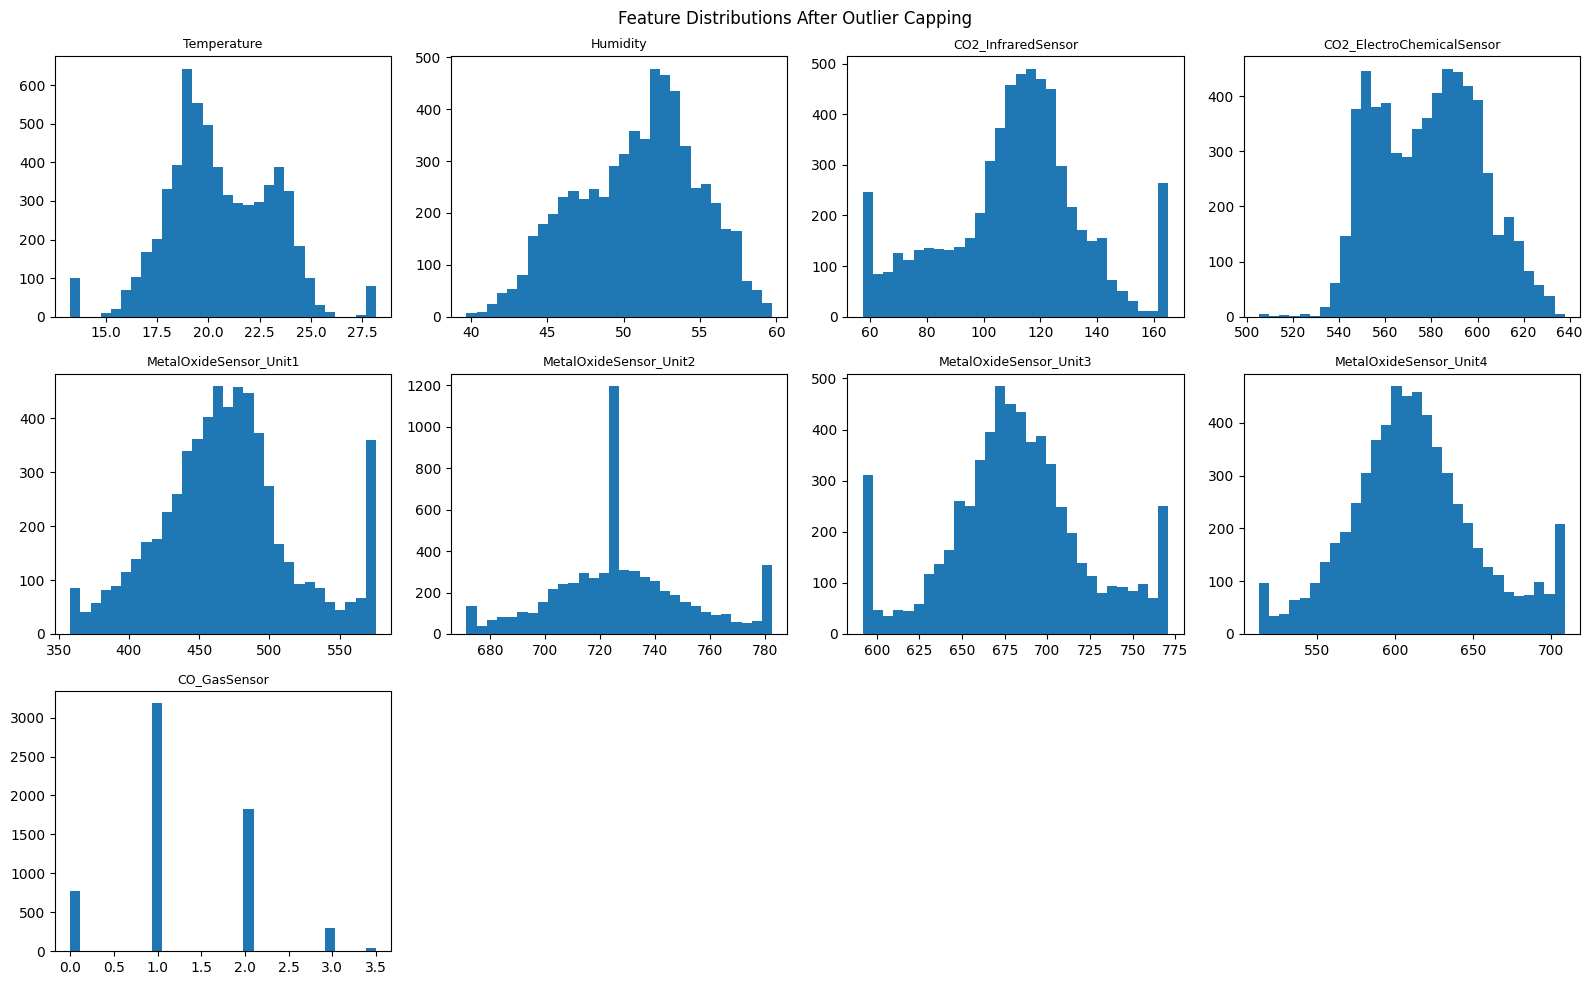

In [29]:
# Visualise distributions after outlier capping
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_columns):
    axes[i].hist(
        df[col].dropna(),
        bins=30
    )

    axes[i].set_title(col, fontsize=9)

for j in range(len(outlier_columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions After Outlier Capping")
plt.tight_layout()
plt.show()

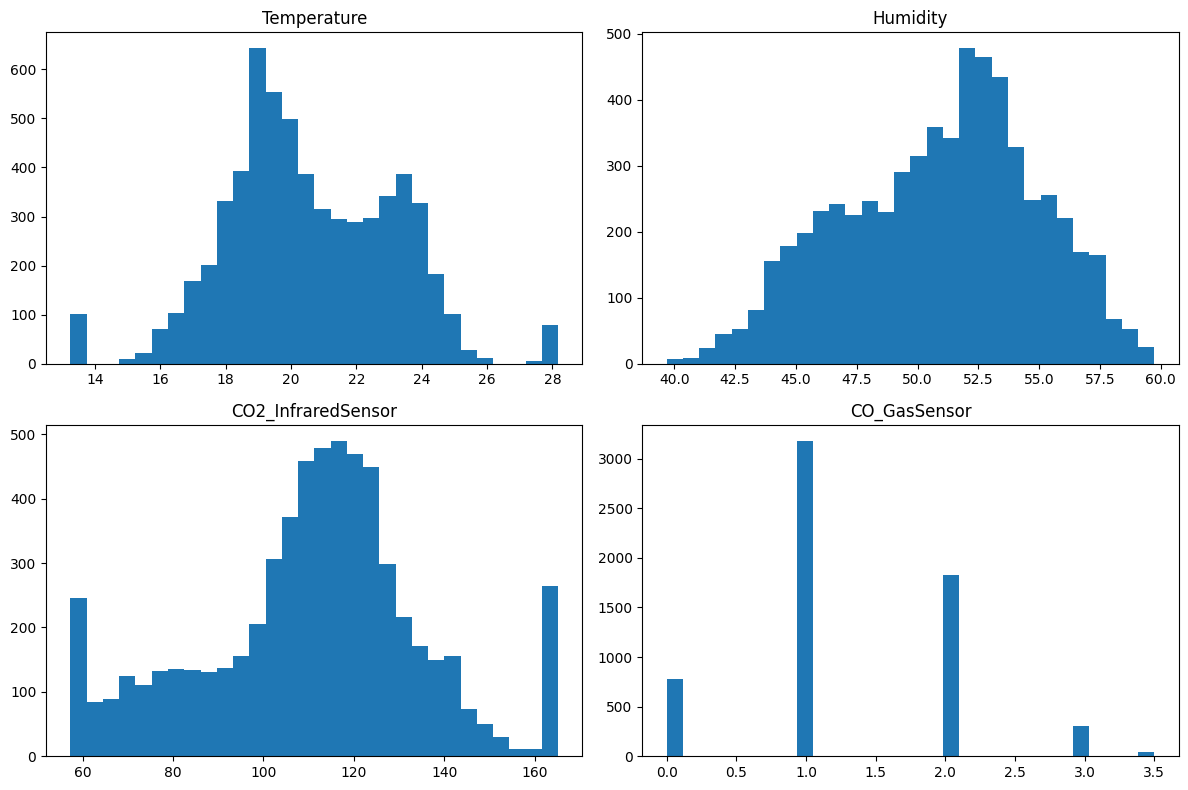

In [30]:
important_cols = [
    "Temperature",
    "Humidity",
    "CO2_InfraredSensor",
    "CO_GasSensor"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(important_cols):

    axes[i].hist(
        df[col],
        bins=30
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Purpose: To identify and reduce the influence of extreme sensor readings that may negatively affect scaling and machine learning performance.

The histograms before outlier handling showed long tails and extreme observations in several sensor features, indicating the presence of statistical outliers. After applying IQR based capping, the extreme values were brought within acceptable ranges while preserving the overall shape of each distribution. This approach reduced the influence of outliers without removing any records from the dataset.

# **7. Encode Categorical Features**

In [31]:
# Identify categorical columns
categorical_cols = [
    "Time of Day",
    "HVAC Operation Mode",
    "Activity Level"
]

print("Categorical Features:")
print(categorical_cols)

Categorical Features:
['Time of Day', 'HVAC Operation Mode', 'Activity Level']


To identify categorical features that require numerical encoding before machine learning.

In [32]:
# Apply one hot encoding
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Encoding complete.")
print(f"Updated dataset shape: {df.shape}")

Encoding complete.
Updated dataset shape: (6140, 22)


To convert categorical labels into numerical format while avoiding ordinal assumptions between categories.

Categorical features were transformed into numerical representations using one hot encoding to ensure compatibility with machine learning algorithms. The first category was dropped during encoding to reduce redundancy and prevent multicollinearity between encoded variables.

# **8. Scale Numerical Features**

In [33]:
# Columns to scale only continuous sensor readings
# Exclude: encoded flags (0/1), ordinal columns, Session ID
all_scale_cols = [
    "Temperature",
    "Humidity",
    "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor",
    "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2",
    "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4",
    "CO_GasSensor",
    "CO2_Disagreement",
    "MOS_Mean"
]

# Filter to include only columns that exist in the DataFrame
scale_cols = [col for col in all_scale_cols if col in df.columns]

# Fit and transform
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

# Verify: scaled columns should have mean ≈ 0 and std ≈ 1
print("Post-scaling stats (should be mean≈0, std≈1):")
print(df_scaled[scale_cols].agg(["mean", "std"]).round(4).to_string())

Post-scaling stats (should be mean≈0, std≈1):
      Temperature  Humidity  CO2_InfraredSensor  CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  MetalOxideSensor_Unit3  MetalOxideSensor_Unit4  CO_GasSensor
mean       0.0000   -0.0000              0.0000                    -0.0000                 -0.0000                 -0.0000                  0.0000                  0.0000       -0.0000
std        1.0001    1.0001              1.0001                     1.0001                  1.0001                  1.0001                  1.0001                  1.0001        1.0001


In [34]:
# Keep both: df (unscaled, interpretable) and df_scaled (ready for modelling)
# For tree-based models (Random Forest, XGBoost) scaling is not needed
# For distance/gradient-based models (KNN, SVM, LogReg) use df_scaled
print(f"df        — original scale, shape: {df.shape}")
print(f"df_scaled — standardised,    shape: {df_scaled.shape}")

df        — original scale, shape: (6140, 22)
df_scaled — standardised,    shape: (6140, 22)


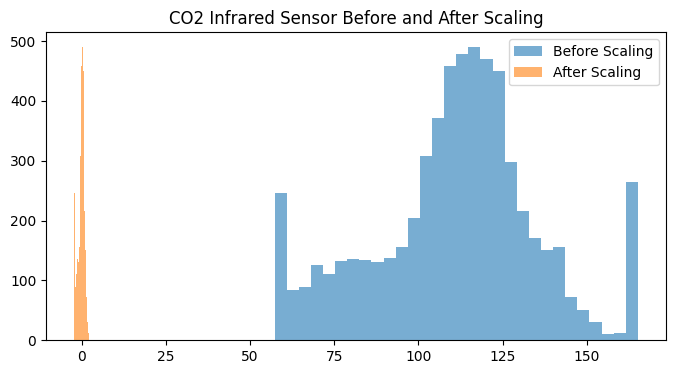

In [35]:
plt.figure(figsize=(8,4))

plt.hist(
    df["CO2_InfraredSensor"],
    bins=30,
    alpha=0.6,
    label="Before Scaling"
)

plt.hist(
    df_scaled["CO2_InfraredSensor"],
    bins=30,
    alpha=0.6,
    label="After Scaling"
)

plt.title("CO2 Infrared Sensor Before and After Scaling")

plt.legend()

plt.show()

To standardize continuous sensor features so that variables with larger numerical ranges do not dominate machine learning models.

Continuous sensor features were standardized using StandardScaler while preserving a separate unscaled version of the dataset for interpretation. Scaling is particularly important for distance based and gradient based machine learning algorithms, while tree based models typically do not require feature scaling.

# **9. Feature Engineering**

In [36]:
# Average MOS Sensor, Reduces noise from individual sensors.
df["MOS_Average"] = (
    df["MetalOxideSensor_Unit1"] +
    df["MetalOxideSensor_Unit2"] +
    df["MetalOxideSensor_Unit3"] +
    df["MetalOxideSensor_Unit4"]
) / 4

The MOS_Average feature was created by combining the Mean Opinion Scores from both ends of the communication. This provides an overall measure of call quality and user satisfaction, making it easier to analyze communication performance.

In [37]:
# CO2 Sensor Difference, Measures disagreement between sensors.
df["CO2_Difference"] = abs(
    df["CO2_InfraredSensor"] -
    df["CO2_ElectroChemicalSensor"]
)

The CO2_Difference feature was created to measure the variation between indoor and outdoor CO₂ levels. This helps identify ventilation effectiveness and highlights environments where air quality may be significantly different from outdoor conditions.

In [38]:
# Indoor Comfort Index, Simple environmental indicator.
df["Comfort_Index"] = (
    df["Temperature"] +
    df["Humidity"]
) / 2

The Comfort_Index feature combines temperature and humidity into a single metric representing environmental comfort. This simplifies analysis by capturing the combined effect of multiple factors that influence occupant comfort.

In [39]:
# High CO Alert, May help classify activity patterns.
df["High_CO"] = (
    df["CO_GasSensor"] >= 3
).astype(int)

The High_CO feature was created as a binary indicator to identify records with elevated carbon monoxide levels. This makes it easier to detect potential air quality concerns and supports classification or risk assessment tasks.

Feature engineering was explored but no additional features were retained as the original sensor measurements already captured the environmental conditions directly and engineered features introduced redundancy without clear predictive value.

# **10. Final Validation**

In [44]:
import numpy as np

# Missing Values
print("Missing Values:")
print(df.isnull().sum())

# Duplicate Rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Dataset Shape
print("\nDataset Shape:")
print(df.shape)

# Data Types
print("\nData Types:")
print(df.dtypes)

# Invalid Temperature Values
print("\nTemperature < 18:")
print((df["Temperature"] < 18).sum())

print("\nTemperature > 40:")
print((df["Temperature"] > 40).sum())

# Invalid Humidity Values
print("\nHumidity < 0:")
print((df["Humidity"] < 0).sum())

print("\nHumidity > 100:")
print((df["Humidity"] > 100).sum())

# Infinite Values
print("\nInfinite Values:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

Missing Values:
Temperature                             0
Humidity                                0
CO2_InfraredSensor                      0
CO2_ElectroChemicalSensor               0
MetalOxideSensor_Unit1                  0
MetalOxideSensor_Unit2                  0
MetalOxideSensor_Unit3                  0
MetalOxideSensor_Unit4                  0
CO_GasSensor                            0
Session ID                              0
Ambient Light Level                     0
Ambient_Light_Ordinal                   0
Time of Day_evening                     0
Time of Day_morning                     0
Time of Day_night                       0
HVAC Operation Mode_eco_mode            0
HVAC Operation Mode_heating_active      0
HVAC Operation Mode_maintenance_mode    0
HVAC Operation Mode_off                 0
HVAC Operation Mode_ventilation_only    0
Activity Level_low activity             0
Activity Level_moderate activity        0
MOS_Average                             0
CO2_Difference    

A final validation check identified 2 remaining duplicate records in the dataset. These duplicates may have appeared after preprocessing and feature engineering steps, where transformations caused previously different records to become identical. Since duplicate observations can introduce bias and affect the reliability of the analysis, the remaining duplicates were removed to ensure that the final dataset contains only unique records.

In [46]:
# Check remaining duplicates
print("Duplicates before removal:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Verify removal
print("Duplicates after removal:", df.duplicated().sum())

Duplicates before removal: 2
Duplicates after removal: 0


**Conclusion:**

The dataset underwent a comprehensive preprocessing process to improve data quality and consistency. Missing numerical values were handled using median imputation to reduce the influence of extreme values, while categorical values were standardized to ensure uniformity across records. Invalid values were corrected, data types were converted to appropriate formats, duplicates were removed, and outliers were treated to minimize their impact on the analysis. Additionally, new features were engineered to capture meaningful patterns and relationships within the data. As a result, the dataset is now cleaner, more reliable, and better prepared for analysis and machine learning applications.